In [12]:
import numpy as np
import matplotlib.pyplot as plt

import pygpufit.gpufit as gf

from SMDutil import SMD
import pathlib
import numpy as np


In [13]:
real_data = SMD(pathlib.Path(r"\\temp-svr\Shared\Bertz\2024\20240819\ppLiNbO3_ND0_50xNA095_circ_XYZ_1_brillouin_processed_processed.hdf5"))

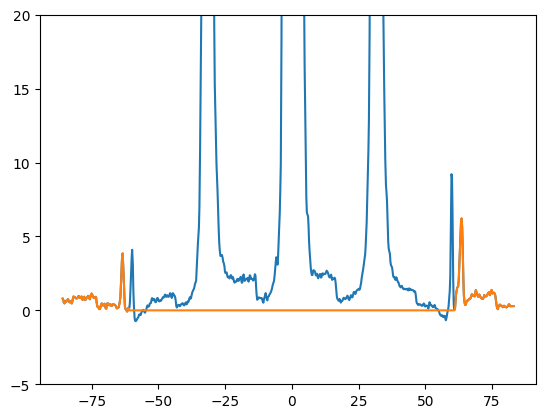

In [14]:
brillouinData = real_data.brillouinChannel.displayData
shift = real_data.brillouinChannel.shift.astype(np.float32)

brillouinData = brillouinData.reshape(np.prod(brillouinData.shape[0:-1]), -1).astype(np.float32)

plt.plot(shift, brillouinData[0,:])
plt.ylim(-5, 20)

startX = np.argmin(np.abs(shift +61))
endX = np.argmin(np.abs(shift - 61))

startX2 = np.argmin(np.abs(shift +70))
endX2 = np.argmin(np.abs(shift - 70))

masked = brillouinData[0,:].copy()
masked[startX:endX] = 0

# masked[0:startX2] = 0
# masked[endX2:] = 0

plt.plot(shift, masked)

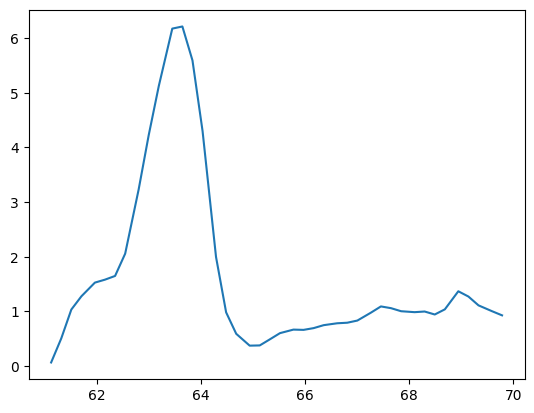

In [15]:
fit_data = brillouinData 
fit_x = shift

startX2 = np.argmin(np.abs(shift - 61))
endX2 = np.argmin(np.abs(shift - 70))

cropX = np.array(shift[startX2:endX2])
cropData = np.array(fit_data[:, startX2:endX2])

plt.plot(cropX, cropData[0,:])

In [16]:
params_initial = np.tile(np.array([15, 63.5, 0.5, 0.1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)

parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit_constrained(cropData, None,
                                                                                                        gf.ModelID.CAUCHY_LORENTZ_1D, params_initial, tolerance=1e-5,  
                                                                                                        estimator_id=gf.EstimatorID.LSE, user_info=cropX,
                                                                                                        n_params=params_initial.shape[-1])

time_gauss
print(n_iterations_gauss, time_gauss)

[4 7 7 ... 6 5 6] 0.07343839999884949


[ 6.112734  63.49645    0.5072718  0.6418842]


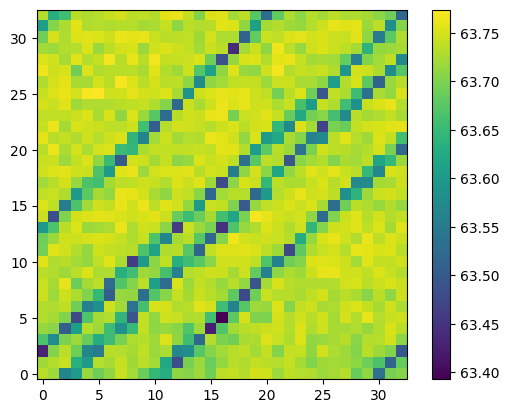

In [17]:
fit_result = parameters_gauss.reshape((real_data.brillouinChannel.displayData.shape[0:-1] + (-1,)))
print(parameters_gauss[0,:])

plt.imshow(fit_result[10,:,:,1], origin='lower')
plt.colorbar()

In [18]:
def lorentzian_peak_1d(x, p):    
    return p[0] * p[2]**2 / ((x-p[1])**2 + p[2]**2) + p[3]

In [19]:
dummy = np.zeros_like(cropData)

for i in range(dummy.shape[0]):
    dummy[i,:] = lorentzian_peak_1d(cropX, [500,65 + np.random.normal(0,1),0.5,1]) + np.random.normal(0,50, size=cropX.size)


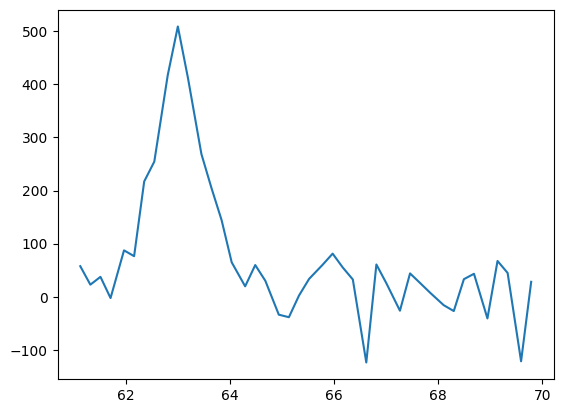

In [20]:
# plt.plot(cropX, cropData[0,:])
plt.plot(cropX, dummy[0,:])

In [21]:
params_initial = np.tile(np.array([5000, 67, 0.5, 1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)

# parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(np.array(dummy), None, gf.ModelID.CAUCHY_LORENTZ_1D, params_initial, 1e-5,  estimator_id=gf.EstimatorID.LSE, user_info=cropX)
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit_constrained(data=dummy, weights=None, model_id=gf.ModelID.CAUCHY_LORENTZ_1D,
                                                                                                     initial_parameters=params_initial,
                                                                                                     user_info=cropX,
                                                                                                     n_params=params_initial.shape[-1]
                                                                                                     

)
print(parameters_gauss[0,:])
print(chi_squares_gauss)
time_gauss


[-247.4625      67.9928       3.6995718  234.09262  ]
[525549.4  683752.   805678.44 ... 503201.   544686.9  635006.3 ]


0.13692460000129358

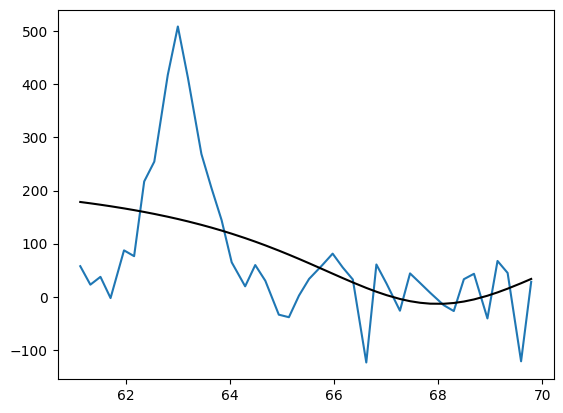

In [22]:
plt.plot(cropX, dummy[0,:])
plt.plot(cropX, lorentzian_peak_1d(cropX, parameters_gauss[0]), color='k')